In [ ]:
import sys
sys.path.insert(0, '.')

import numpy as np

import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

import loadmat as lm

# 1 Data and pre-processing
## 1.1 Loading

In [ ]:
# Columns: 0-7 EEG, 8 time (s), 9 stimulus code (1-6 rows, 7-12 columns), 10 infrequent label
data = lm.loadmat('P300data.mat')['data']
training = np.asarray(data['training'], dtype=float)   # (nbSamples, nbChannels)
testing = np.asarray(data['testing'], dtype=float)     # (nbSamples, nbChannels-1)

# Electrodes as per task description
electrodes = {0: 'Fz', 1: 'Cz', 2: 'P3', 3: 'Pz', 4: 'P4', 5: 'PO7', 6: 'Oz', 7: 'PO8'}
n_ch = len(electrodes)

# Sampling rate from the time column
fs = 1.0 / np.median(np.diff(training[:, 8]))

print(f'training: {training.shape}')
print(f'testing:  {testing.shape}')
print(f'fs:       {fs:.2f} Hz')

training: (255743, 11)
testing:  (97765, 10)
fs:       250.00 Hz


## 1.2 Bandpass filter

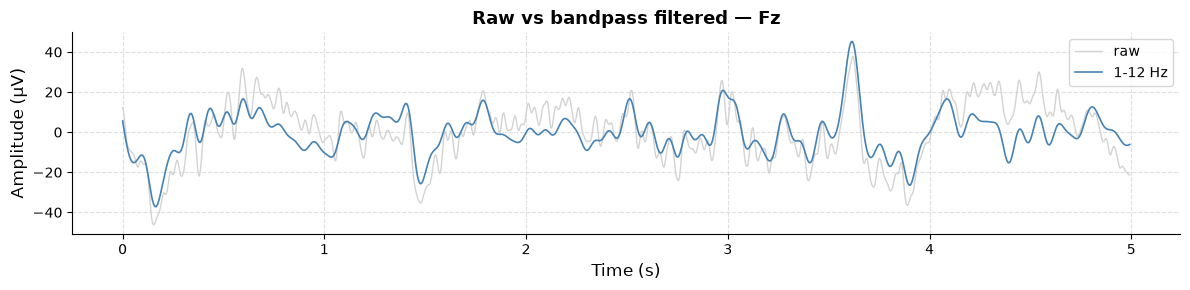

In [ ]:
# Zero-phase Butterworth bandpass, 1 - 12 Hz
b, a = butter(N=4, Wn=[1.0, 12.0], btype='bandpass', fs=fs)  # type: ignore

# Setup filters
eeg_train = filtfilt(b, a, training[:, :n_ch], axis=0)
eeg_test = filtfilt(b, a, testing[:, :n_ch], axis=0)

# Plot raw vs filtered signal
seg = slice(0, int(5 * fs))
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(training[seg, 8], training[seg, 0], color='lightgray', linewidth=1.0, label='raw')
ax.plot(training[seg, 8], eeg_train[seg, 0], color='steelblue', linewidth=1.2, label='1-12 Hz')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title(f'Raw vs bandpass filtered — {electrodes[0]}', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 2 Training epochs
## 2.1 Stimulus-locked epochs

In [ ]:
# Each epoch centered [-100 ms, +800 ms] around stimulus onset
n_pre = int(round(-0.1 * fs))
n_post = int(round(0.8 * fs))
base_n = -n_pre

# Extracts epoch onsets
def stim_onsets(arr, n_samples):
    onsets = np.flatnonzero(arr[:, 9] != 0)
    keep = (onsets + n_pre >= 0) & (onsets + n_post <= n_samples)
    return onsets[keep]

# Extracts epoch slices
def epoch(eeg, onsets):
    # (n_epochs, n_samples, n_channels)
    return np.stack([eeg[o+n_pre:o+n_post] for o in onsets])

onsets_tr = stim_onsets(training, len(eeg_train))
# Labels (stimulus code + impulse type)
codes_tr = training[onsets_tr, 9].astype(int)
y_tr = (training[onsets_tr, 10] != 0).astype(int)
ep_tr = epoch(eeg_train, onsets_tr)

print(f'epochs: {ep_tr.shape}   infrequent: {y_tr.sum()}   frequent: {(y_tr == 0).sum()}')

epochs: (3000, 225, 8)   infrequent: 500   frequent: 2500


## 2.2 Class-averaged ERPs

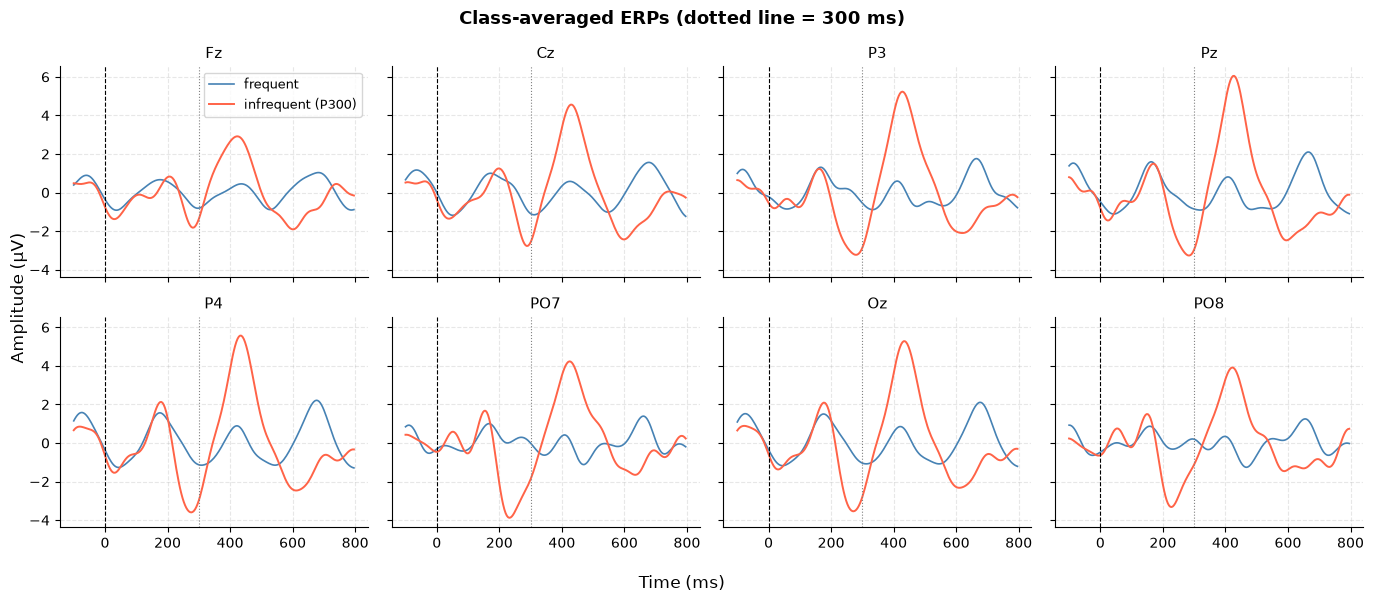

In [ ]:
t_ep = np.arange(n_pre, n_post) / fs * 1000

# Split into frequent & infrequent
erp_target = ep_tr[y_tr == 1].mean(axis=0)
erp_standard = ep_tr[y_tr == 0].mean(axis=0)

# Plot class-averaged ERPs against time for each electrode
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
for ch, ax in enumerate(axes.ravel()):
    ax.plot(t_ep, erp_standard[:, ch], color='steelblue', linewidth=1.2, label='frequent')
    ax.plot(t_ep, erp_target[:, ch], color='tomato', linewidth=1.4, label='infrequent (P300)')
    ax.axvline(0, color='k', linewidth=0.8, linestyle='--')
    ax.axvline(300, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(electrodes[ch], fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.3)

axes[0, 0].legend(fontsize=9)
fig.supxlabel('Time (ms)', fontsize=12)
fig.supylabel('Amplitude (µV)', fontsize=12)
fig.suptitle('Class-averaged ERPs (dotted line = 300 ms)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 3 Single-trial classification
## 3.1 Feature extraction

In [ ]:
def features(epochs, b=6):
    # Baseline correction, ensures relative starting points
    base = epochs[:, :base_n, :].mean(axis=1, keepdims=True)
    post = epochs[:, base_n:, :] - base
    # Average remaining samples into blocks of size b
    n = (post.shape[1] // b) * b
    post = post[:, :n].reshape(post.shape[0], n // b, b, post.shape[2]).mean(axis=2)
    # Flatten into feature vector (samples * electrodes)
    return post.reshape(post.shape[0], -1)

# Build feature vector
X_tr = features(ep_tr)
print('feature matrix:', X_tr.shape)

feature matrix: (3000, 264)


## 3.2 K-fold cross-validated ROC / AUC

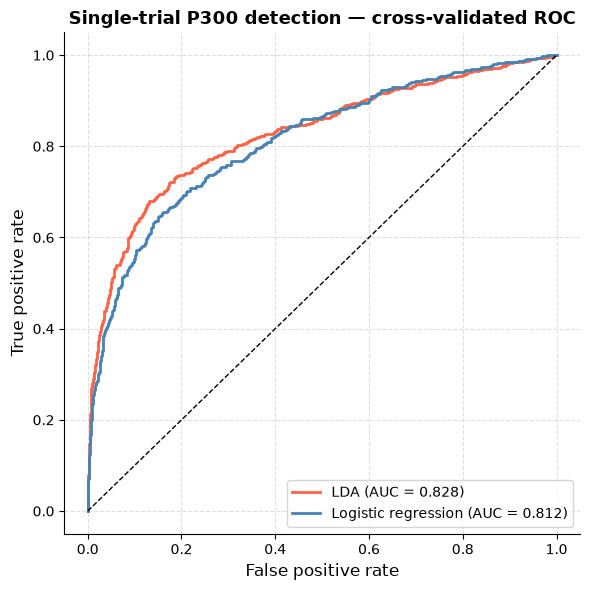

In [ ]:
# Build LDA & LogReg classifiers
lda = make_pipeline(StandardScaler(),
                    LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'))
log = make_pipeline(StandardScaler(),
                    LogisticRegression(max_iter=2000, class_weight='balanced'))

# K-fold cross validation, due to large class imbalance (1:5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Plot ROC / AUC for both classifiers
fig, ax = plt.subplots(figsize=(6, 6))
for name, clf, color in [('LDA', lda, 'tomato'), ('Logistic regression', log, 'steelblue')]:
    scores = cross_val_predict(clf, X_tr, y_tr, cv=cv, method='decision_function')
    fpr, tpr, _ = roc_curve(y_tr, scores)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

ax.plot([0, 1], [0, 1], color='k', linestyle='--', linewidth=1)
ax.set_xlabel('False positive rate', fontsize=12)
ax.set_ylabel('True positive rate', fontsize=12)
ax.set_title('Single-trial P300 detection — cross-validated ROC', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## 3.3 Class separation

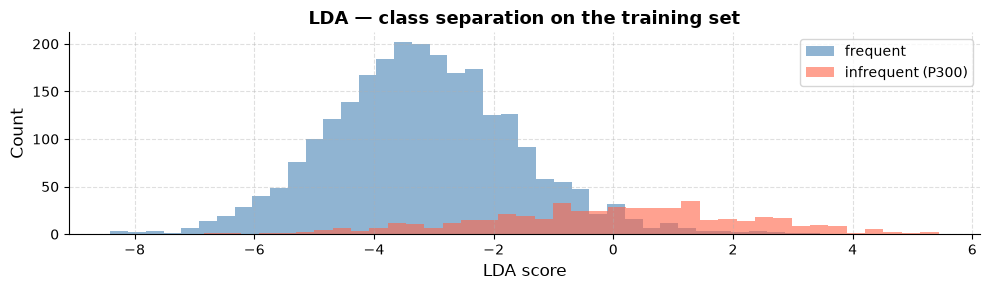

In [ ]:
# LDA has better ROC, fit data
lda.fit(X_tr, y_tr)
proj = lda.decision_function(X_tr)

# Plot class separation on training data
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(proj[y_tr == 0], bins=40, color='steelblue', alpha=0.6, label='frequent')
ax.hist(proj[y_tr == 1], bins=40, color='tomato', alpha=0.6, label='infrequent (P300)')
ax.set_xlabel('LDA score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('LDA — class separation on the training set', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# 4 Speller decoding
## 4.1 Sequence segmentation

In [ ]:
# Donchin matrix from the slides
letter_mat = np.array([
    ['A', 'B', 'C', 'D', 'E', 'F'],
    ['G', 'H', 'I', 'J', 'K', 'L'],
    ['M', 'N', 'O', 'P', 'Q', 'R'],
    ['S', 'T', 'U', 'V', 'W', 'X'],
    ['Y', 'Z', '1', '2', '3', '4'],
    ['5', '6', '7', '8', '9', '_'],
])

# Split into sequences (each of 2*6=12 cols/rows should flash once)
def segment_sequences(codes):
    seqs, cur, seen = [], [], set()
    for i, code in enumerate(codes):
        if code in seen:
            seqs.append(cur)
            cur, seen = [], set()
        cur.append(i)
        seen.add(code)
    if cur:
        seqs.append(cur)
    return seqs

# Determine sequence boundaries
seqs_tr = segment_sequences(codes_tr)

# Extract sequence targets
targets = []
for s in seqs_tr:
    idx = np.array(s)
    inf = codes_tr[idx[y_tr[idx] == 1]]
    row, col = inf[inf <= 6], inf[inf >= 7]
    targets.append((int(row[0]) if len(row) else 0, int(col[0]) if len(col) else 0))

# Determine repetitions
runs, run = [], 1
for k in range(1, len(targets)):
    if targets[k] == targets[k - 1]:
        run += 1
    else:
        runs.append(run)
        run = 1
runs.append(run)
S = int(np.median(runs))

print(f'sequences: {len(seqs_tr)}   sequences/letter: {S}   letters: {len(seqs_tr) // S}')

sequences: 250   sequences/letter: 10   letters: 25


## 4.2 Decoding the training words

In [ ]:
# Decode based on classifier scores
def decode(scores, codes, seqs, S):
    word = []
    for letter in range(len(seqs) // S):
        block = np.array([i for s in seqs[letter * S:(letter + 1) * S] for i in s])
        # Pool repetition scores into one number / code
        acc = {code: scores[block][codes[block] == code].mean() for code in range(1, 13)}
        # Maximum accuracy = selected row / col
        row = max(range(1, 7), key=lambda code: acc[code])
        col = max(range(7, 13), key=lambda code: acc[code])
        word.append(letter_mat[row - 1, col - 7])
    return ''.join(word)

# Check against validation word
true_word = ''.join(letter_mat[r - 1, c - 7] for r, c in targets[::S] if r and c)
insample_word = decode(lda.decision_function(X_tr), codes_tr, seqs_tr, S)

print('true letters:    ', true_word)
print('in-sample decode:', insample_word)

true letters:     TOKENMIRARJUJUYMANSOCINCO
in-sample decode: TOKENMIRARJUJUYMANSOCINCO


# 5 Decoding the testing set

In [ ]:
# Setup test data
onsets_te = stim_onsets(testing, len(eeg_test))
codes_te = testing[onsets_te, 9].astype(int)
X_te = features(epoch(eeg_test, onsets_te))
seqs_te = segment_sequences(codes_te)

# Fit both models
lda.fit(X_tr, y_tr)
log.fit(X_tr, y_tr)

# Decode using both models
word_lda = decode(lda.decision_function(X_te), codes_te, seqs_te, S)
word_log = decode(log.decision_function(X_te), codes_te, seqs_te, S)

print(f'sequences: {len(seqs_te)}   letters: {len(seqs_te) // S}')
print('LDA decode:     ', word_lda)
print('Logistic decode:', word_log)

sequences: 80   letters: 8
LDA decode:      JUEGOQUE
Logistic decode: JUEGOQUE
